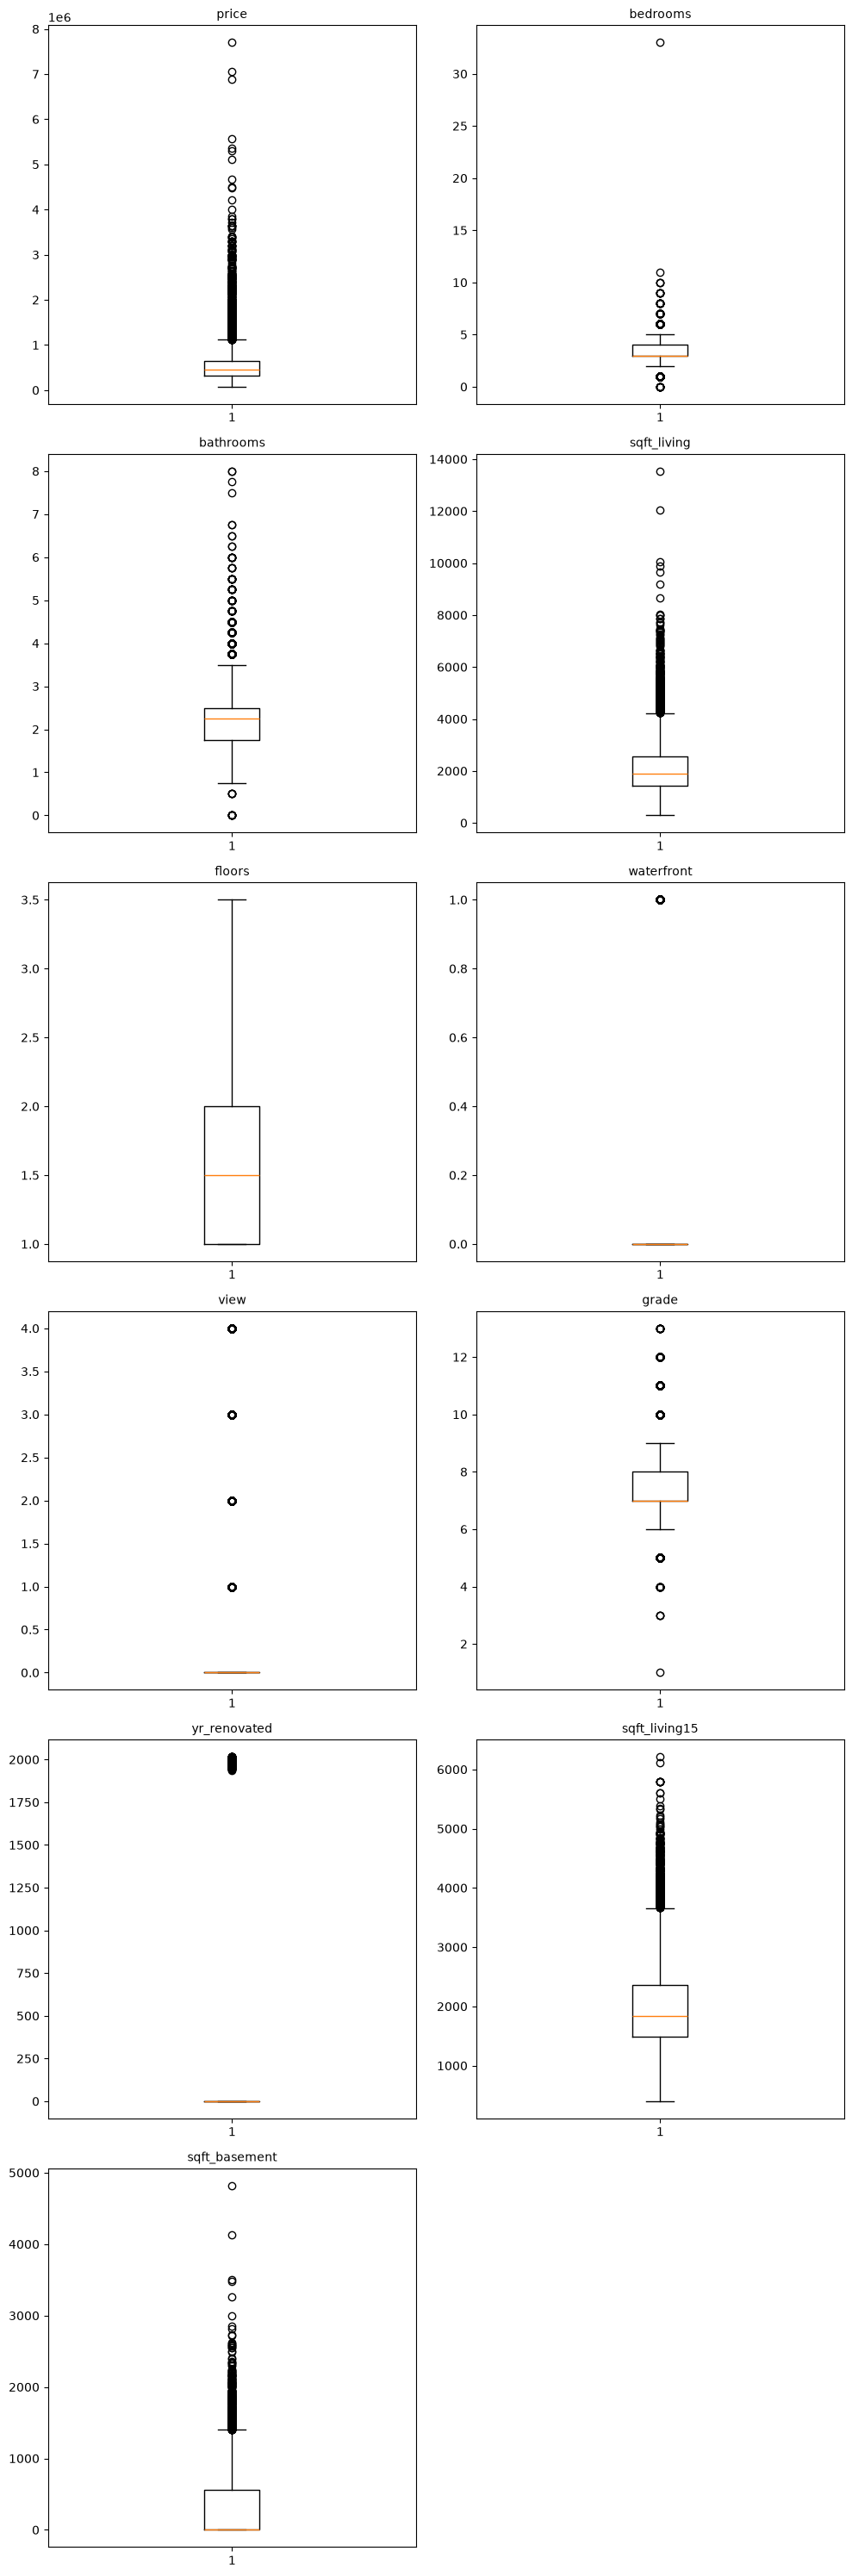

              price      bedrooms     bathrooms   sqft_living        floors  \
count  2.161300e+04  21613.000000  21613.000000  21613.000000  21613.000000   
mean   5.401822e+05      3.370842      2.114757   2079.899736      1.494309   
std    3.673622e+05      0.930062      0.770163    918.440897      0.539989   
min    7.500000e+04      0.000000      0.000000    290.000000      1.000000   
25%    3.219500e+05      3.000000      1.750000   1427.000000      1.000000   
50%    4.500000e+05      3.000000      2.250000   1910.000000      1.500000   
75%    6.450000e+05      4.000000      2.500000   2550.000000      2.000000   
max    7.700000e+06     33.000000      8.000000  13540.000000      3.500000   

         waterfront          view         grade  yr_renovated  sqft_living15  \
count  21613.000000  21613.000000  21613.000000  21613.000000   21613.000000   
mean       0.007542      0.234303      7.656873     84.402258    1986.552492   
std        0.086517      0.766318      1.175459 

In [30]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
#------------------------------------------data Quality----------------
#1-completeness
#2-uniqueness
#3-timelinces
# 4-valid
# 5-consistency
#accuricy #

#encoding + corr + outliers + feature transformation
df=pd.read_csv("kc_house_data.csv")

df.drop(['id','zipcode', 'lat', 'long'],axis=1,inplace=True)

df['date']=df['date'].apply(lambda x:x.split('T')[0])
df['date']=pd.to_datetime(df['date'])
df['sale_year']=df['date'].dt.year
df['age']=df['sale_year']-df['yr_built']

# print(df.columns)
# sns.heatmap(df.corr(),annot=True)
# plt.show()

df.drop('sqft_above',axis=1,inplace=True) # hight corr with sqft_living leading to multicolinarity

df.drop(['sale_year', 'sqft_lot', 'sqft_lot15', 'yr_built', 'condition','age','date'],axis=1,inplace=True) # low correlation with the price


fix,axis=plt.subplots(6,2, figsize=(10, 30))
# sns.heatmap(df.corr(),annot=True)
# plt.show()
n=0 
for i in range(6):
    for l in range(2):
        if n<len(df.columns):

        
            axis[i,l].boxplot(df.iloc[:,n])
            axis[i, l].set_title(df.columns[n], fontsize=10)
            n+=1
        else :
            axis[i, l].axis('off')

            
plt.tight_layout()
plt.show()
print(df.describe())
print(df.shape)
df.to_csv('dataAfterPre.csv')

In [31]:
# فحص العقارات التي تحتوي على 0 حمامات لمعرفة أسعارها ومساحاتها
print(df[df['bathrooms'] == 0][['price', 'sqft_living', 'bedrooms']])


           price  sqft_living  bedrooms
875    1100000.0         3064         0
1149     75000.0          670         1
3119    380000.0         1470         0
5832    280000.0          600         1
6994   1300000.0         4810         0
9773    355000.0         2460         0
9854    235000.0         1470         0
10481   484000.0          690         1
14423   139950.0          844         0
19452   142000.0          290         0


In [32]:
df=df[~((df['bathrooms']==0)&(df['sqft_living']>1000))]
df=df[df['bedrooms']<=15]
print(df[df['bathrooms']==0][['price','sqft_living','bedrooms']])

print(df.describe())

          price  sqft_living  bedrooms
1149    75000.0          670         1
5832   280000.0          600         1
10481  484000.0          690         1
14423  139950.0          844         0
19452  142000.0          290         0
              price      bedrooms     bathrooms   sqft_living        floors  \
count  2.160700e+04  21607.000000  21607.000000  21607.000000  21607.000000   
mean   5.401466e+05      3.370250      2.115264   2079.787985      1.494099   
std    3.673469e+05      0.906639      0.769594    918.328490      0.539751   
min    7.500000e+04      0.000000      0.000000    290.000000      1.000000   
25%    3.217250e+05      3.000000      1.750000   1423.500000      1.000000   
50%    4.500000e+05      3.000000      2.250000   1910.000000      1.500000   
75%    6.450000e+05      4.000000      2.500000   2550.000000      2.000000   
max    7.700000e+06     11.000000      8.000000  13540.000000      3.500000   

         waterfront          view         grade  yr_re

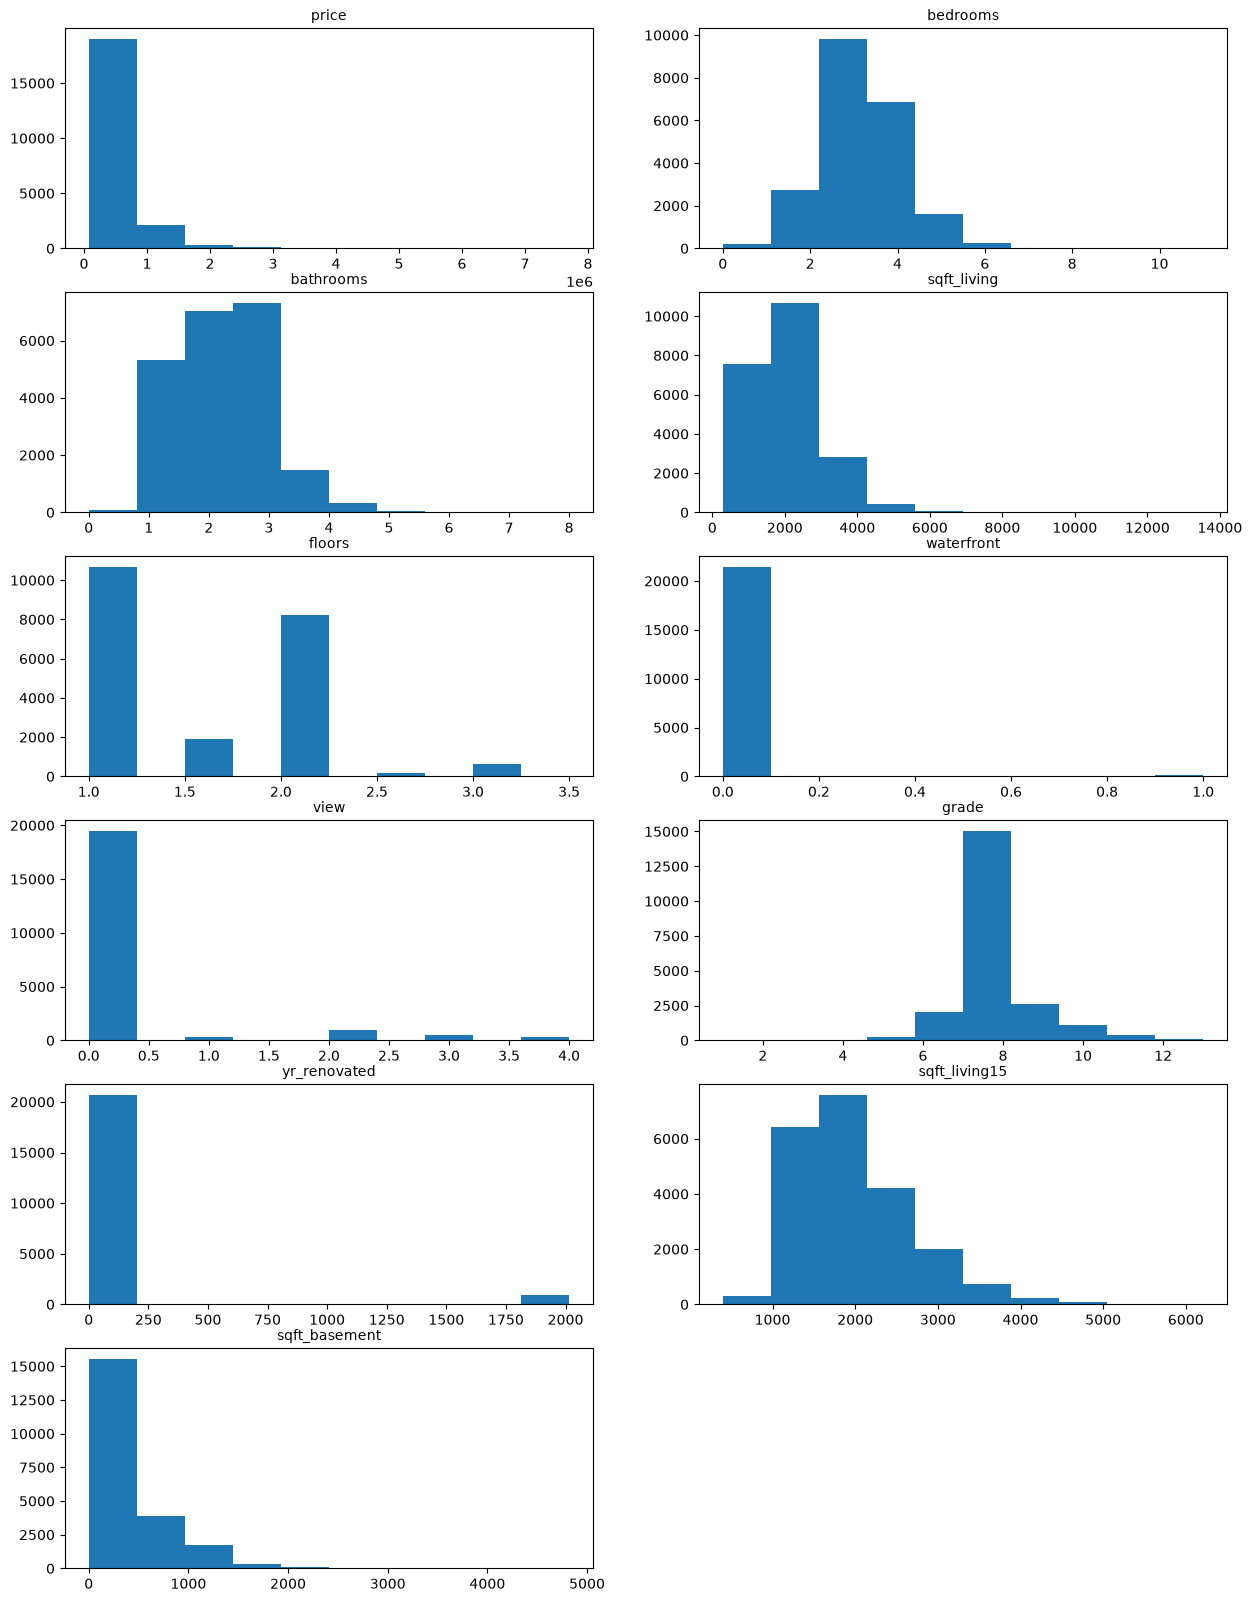

In [33]:
m=0
fig,axis=plt.subplots(6,2, figsize=(15, 20))

for i in range(6):
    for l in range(2):
        if m<len(df.columns):
            axis[i,l].hist(df.iloc[:,m])
            axis[i,l].set_title(df.columns[m],fontsize=10)
            m+=1
        else :
            axis[i, l].axis('off')
plt.show()

In [35]:
df['sqft_living']=np.log1p(df['sqft_living'])
df['basement_existant']=(df['sqft_basement']>0).astype(int)
df['sqft_living15']=np.log1p(df['sqft_living15'])
df['price']=np.log1p(df['price'])
df['waterfront']=(df['waterfront']>0).astype(int)
df['yr_renovated']=(df['yr_renovated']>0).astype(int)

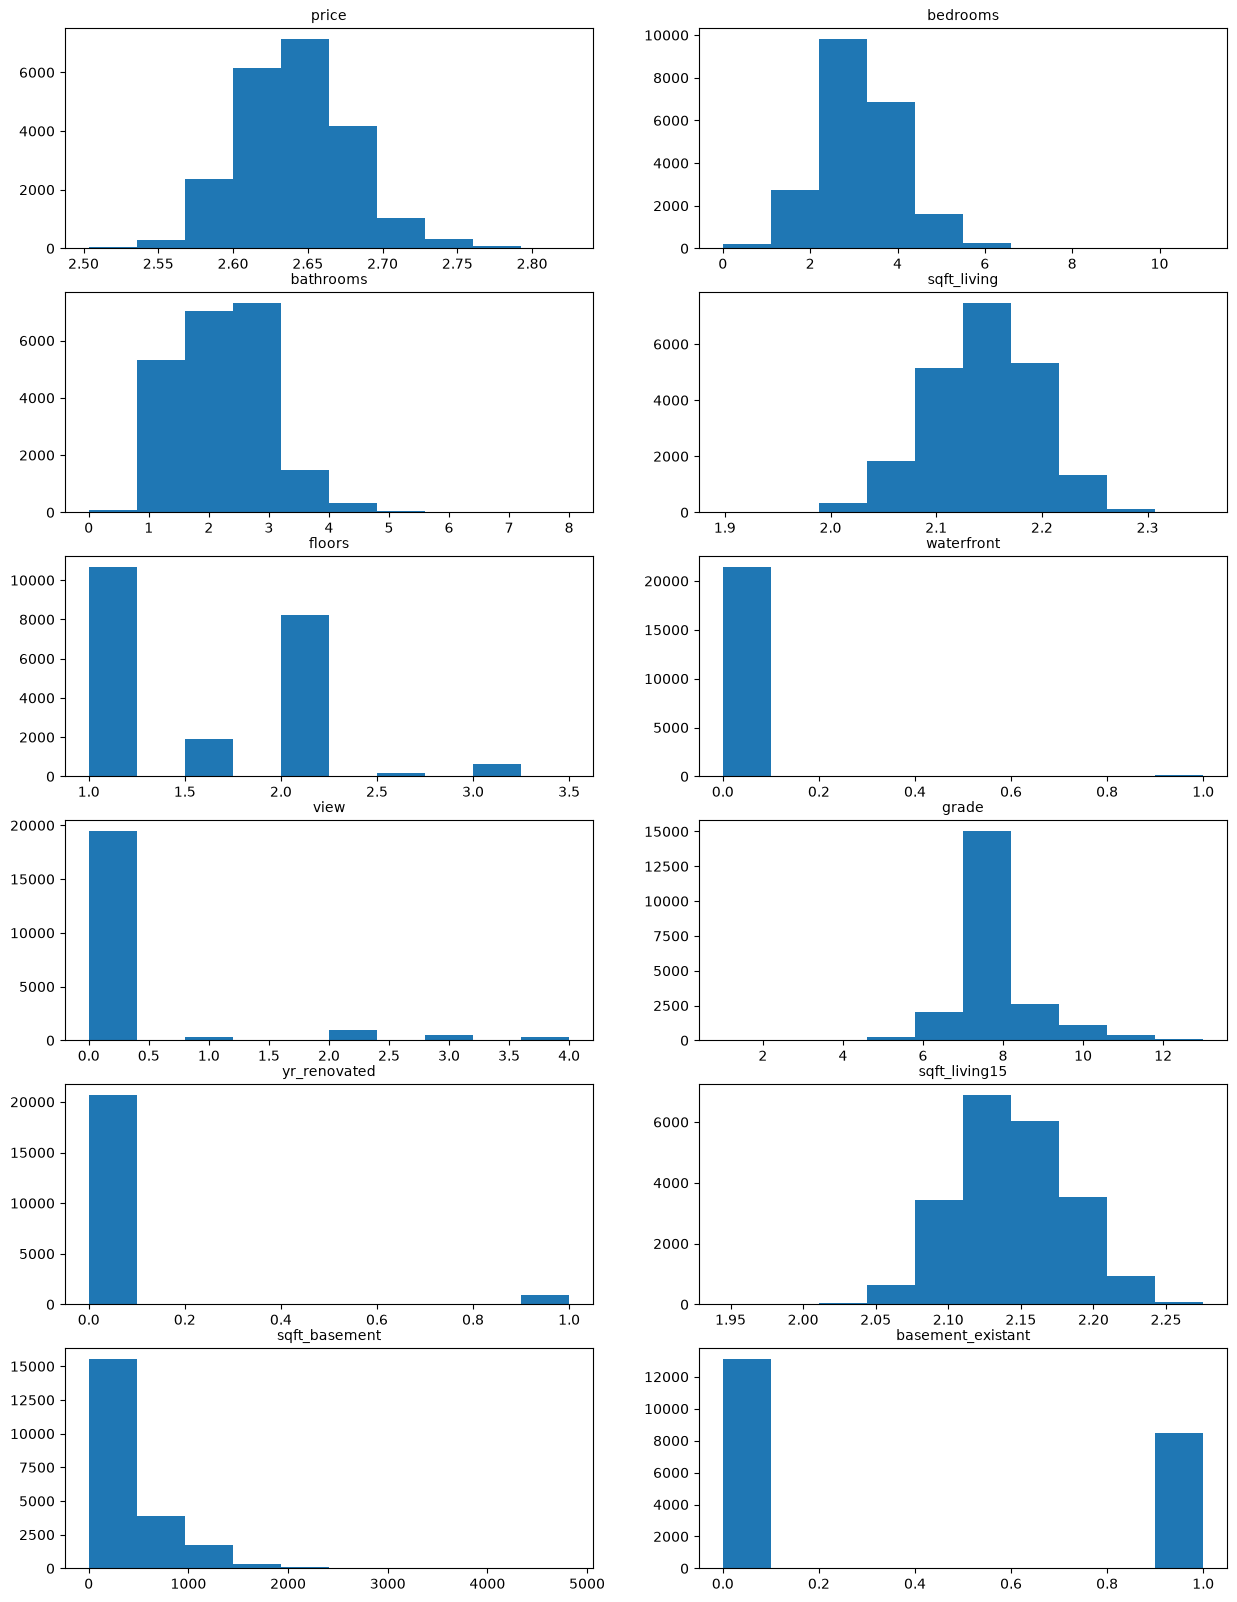

In [36]:
m=0
fig,axis=plt.subplots(6,2, figsize=(15, 20))

for i in range(6):
    for l in range(2):
        if m<len(df.columns):
            axis[i,l].hist(df.iloc[:,m])
            axis[i,l].set_title(df.columns[m],fontsize=10)
            m+=1
        else :
            axis[i, l].axis('off')
plt.show()